<a href="https://colab.research.google.com/github/Monuj123/SpeechRecognition/blob/main/WorkingWithAudioFile.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import librosa

In [2]:
audio_path="harvard.wav"

In [3]:
signal,sample_rate=librosa.load(audio_path,sr=None)

In [4]:
print(signal)

[ 0.0000000e+00  1.5258789e-05 -3.0517578e-05 ... -1.7395020e-03
 -1.7547607e-03 -1.8463135e-03]


In [5]:
signal.size

809508

In [34]:
sample_rate #or sampling frequency

44100

In [7]:
duration=len(signal)/sample_rate #duration of the audio file in seconds
print(duration)

18.356190476190477


**Visualize**

In [8]:
import matplotlib.pyplot as plt
import librosa.display

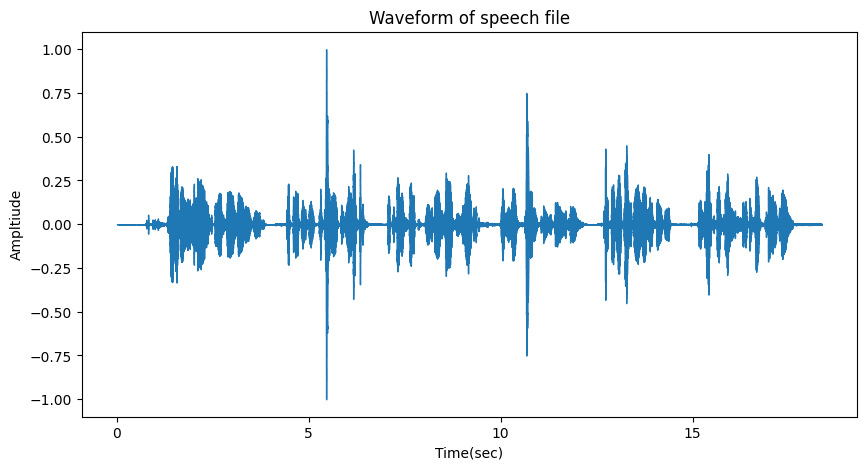

In [9]:
plt.figure(figsize=(10,5))
librosa.display.waveshow(signal,sr=sample_rate)
plt.title("Waveform of speech file")
plt.xlabel("Time(sec)")
plt.ylabel("Ampltiude")
plt.show()

**Playing an audio file**

In [10]:
from IPython.display import Audio

In [11]:
Audio(signal, rate=sample_rate)

**Spectogram**

In [22]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np


In [23]:
audio, sr = librosa.load("harvard.wav")

In [24]:
# Apply Short-Time Fourier Transform (STFT)
stft = librosa.stft(audio)

In [25]:
# Convert amplitude to decibels (dB)
spectrogram = librosa.amplitude_to_db(np.abs(stft))


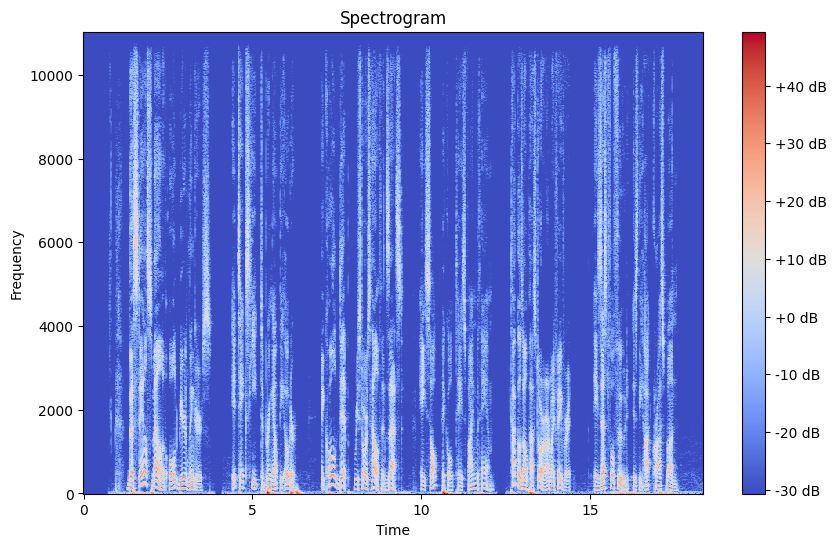

In [26]:
# Plot spectrogram
plt.figure(figsize=(10, 6))
librosa.display.specshow(spectrogram, sr=sr, x_axis='time', y_axis='hz')

plt.colorbar(format='%+2.0f dB')
plt.title("Spectrogram")
plt.xlabel("Time")
plt.ylabel("Frequency")

plt.show()

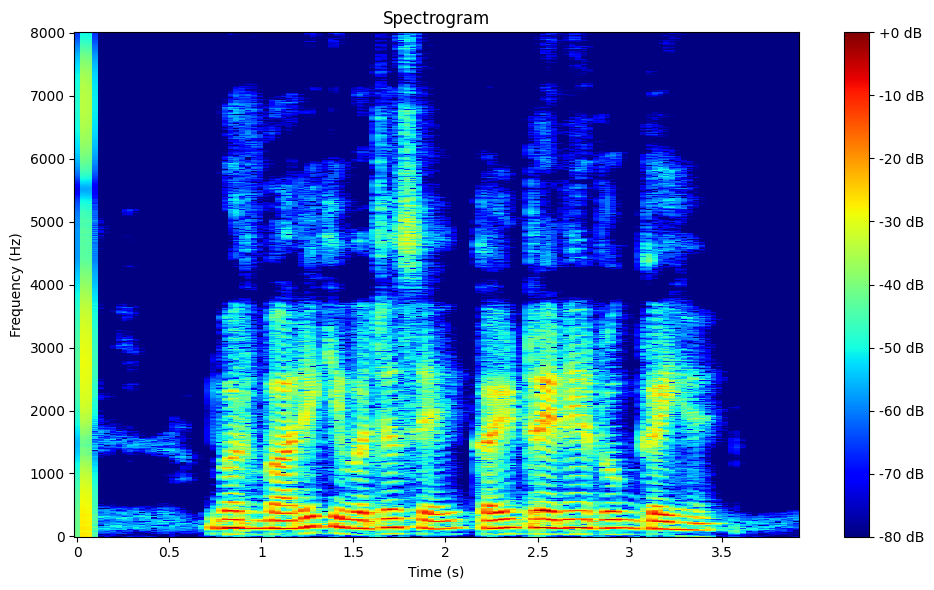

In [57]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

# Load audio file (keep original sample rate)
audio, sr = librosa.load("hindi.wav", sr=None)

# Apply STFT with better parameters
stft = librosa.stft(audio, n_fft=2048, hop_length=512)

# Convert amplitude to decibels (VERY IMPORTANT FIX)
spectrogram = librosa.amplitude_to_db(np.abs(stft), ref=np.max)

# Plot spectrogram
plt.figure(figsize=(10, 6))

librosa.display.specshow(
    spectrogram,
    sr=sr,
    hop_length=512,
    x_axis='time',
    y_axis='linear',   # IMPORTANT (not 'hz' or 'log')
    cmap='jet'         # 🔥 gives green → yellow → red
)

plt.colorbar(format='%+2.0f dB')
plt.title("Spectrogram")
plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")

plt.tight_layout()
plt.show()

**Mel Spectogram**

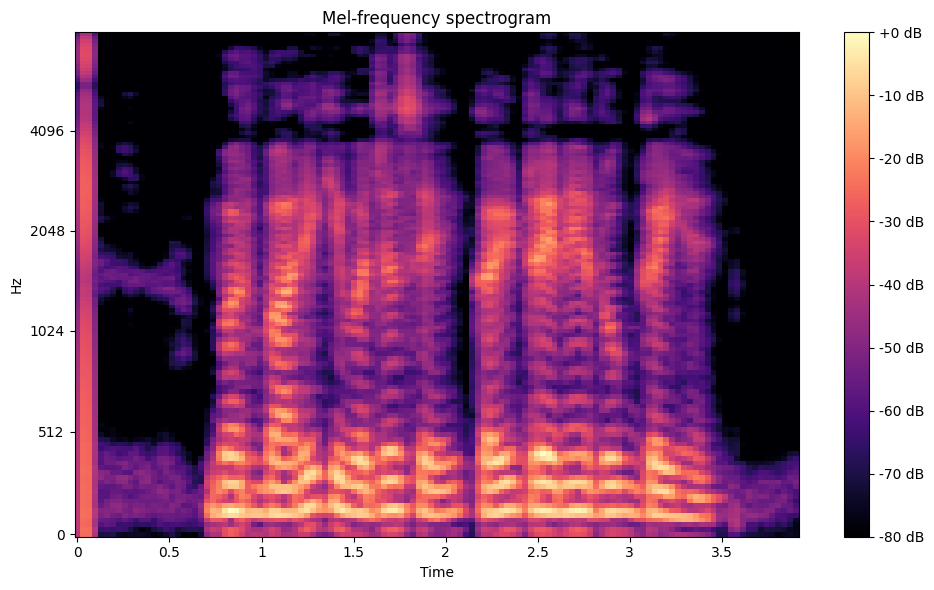

In [60]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

# Compute mel spectrogram
melspectrogram = librosa.feature.melspectrogram(y=audio, sr=sr)

# Convert to decibels for visualization
melspectrogram_db = librosa.power_to_db(melspectrogram, ref=np.max)

# Plot the mel spectrogram
plt.figure(figsize=(10, 6))
librosa.display.specshow(melspectrogram_db, sr=sr, x_axis='time', y_axis='mel')
plt.colorbar(format='%+2.0f dB')
plt.title('Mel-frequency spectrogram')
plt.tight_layout()
plt.show()

**Log Mel Spectogram**

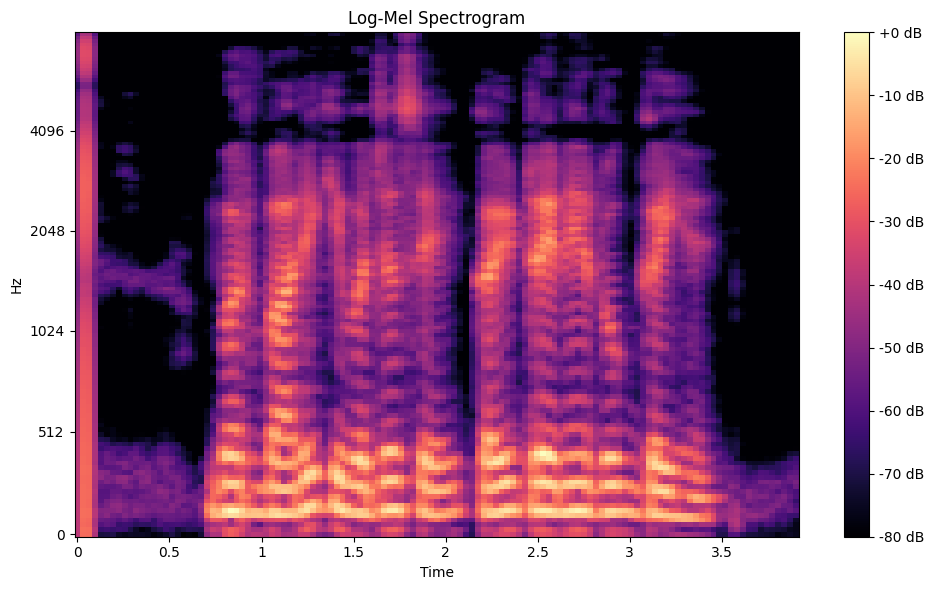

In [61]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
# Load audio file
audio, sr = librosa.load("hindi.wav", sr=None)

# Step 1: Create Mel Spectrogram
mel_spec = librosa.feature.melspectrogram(
    y=audio,
    sr=sr,
    n_fft=2048,        # window size
    hop_length=512,    # step size
    n_mels=128         # number of Mel bands
)

# Step 2: Convert to Log scale (dB)
log_mel_spec = librosa.power_to_db(mel_spec, ref=np.max)

# Step 3: Visualize
plt.figure(figsize=(10, 6))
librosa.display.specshow(
    log_mel_spec,
    sr=sr,
    hop_length=512,
    x_axis='time',
    y_axis='mel'
)
plt.colorbar(format='%+2.0f dB')
plt.title('Log-Mel Spectrogram')
plt.tight_layout()
plt.show()

**Dominant Frequency of the audio**

In [36]:
import numpy as np
import librosa

# Load audio
audio, sr = librosa.load("hindi.wav", sr=None)

# FFT
fft = np.fft.fft(audio)
frequencies = np.fft.fftfreq(len(fft), 1/sr)

# Magnitude
magnitude = np.abs(fft)

# Get dominant frequency
peak_freq = frequencies[np.argmax(magnitude)]

print("Dominant Frequency:", abs(peak_freq), "Hz")

Dominant Frequency: 138.372593052702 Hz


**MFCC features extraction**

In [37]:
audio, sr = librosa.load("hindi.wav", sr=None)


In [68]:
# Extract MFCC features
mfccs = librosa.feature.mfcc(
    y=audio,
    sr=sr,
    n_mfcc=13   # number of coefficients (standard)
).T


In [69]:
print("MFCC shape:", mfccs.shape)#(no. of time frames with overlap,13 MFCC coefficients)

MFCC shape: (123, 13)


In [44]:
print(mfccs)

[[-280.76926     42.737984     1.019386  ...    1.0954312    4.540119
    -3.2157443]
 [-120.20729     41.787712     2.3631449 ...    1.0460098    4.8006
    -3.0861373]
 [-125.633224    41.37264      2.9497156 ...    1.0114791    4.891856
    -3.0081086]
 ...
 [-639.5506      38.02424     34.850616  ...  -12.529758   -14.407547
   -14.816534 ]
 [-639.4891      37.92714     34.232895  ...  -15.132462   -15.852527
   -14.967276 ]
 [-641.42834     35.114098    31.222452  ...  -17.854206   -17.77586
   -15.996651 ]]


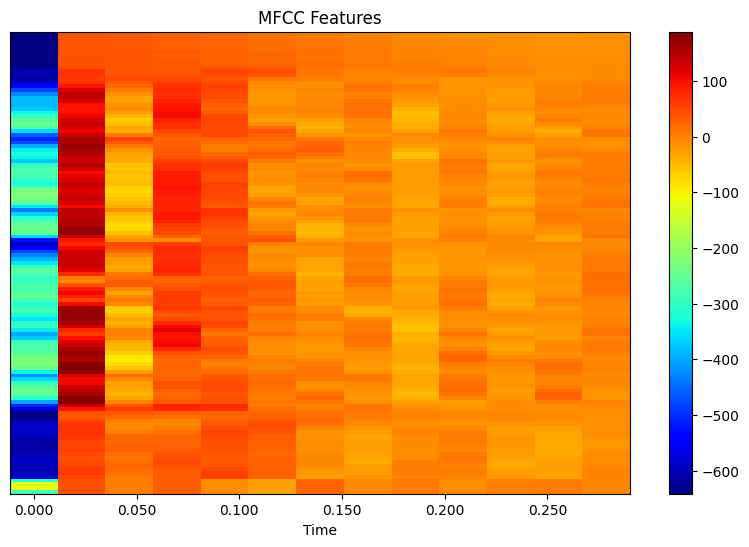

In [70]:
import matplotlib.pyplot as plt
import librosa.display

plt.figure(figsize=(10, 6))

librosa.display.specshow(
    mfccs,
    x_axis='time',
    cmap='jet'
)

plt.colorbar()
plt.title("MFCC Features")

plt.show()